<a href="https://colab.research.google.com/github/asheldrick-research/Wide-Binaries-analysis/blob/main/ECSM_NG2R_EXECUTED_Inertia_and_Static_Gravitational_Response_from_One_Matter_Medium_Coupling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ECSM NG2R — Inertia and Static Gravitational Response from One Matter–Medium Coupling

NG2R is the second notebook in the rebuilt non-geometric ECSM chain.

NG1R established a stable primitive medium with density, phase, coherence, constitutive tensor, orientation, and relaxation variables. NG2R isolates the **gapless longitudinal collective response coordinate** of that parent system and asks whether one matter–medium coupling can generate both:

1. inertial resistance under acceleration; and
2. a static long-range attraction with an inverse-square exterior.

No physical spacetime metric, curvature tensor, Einstein equation, geodesic equation, or curved-space potential is used.

The core physical chain is

\[
\boxed{
\text{one source coupling}
\rightarrow
\text{local response dressing}
\rightarrow
\text{added inertia}
}
\]

and simultaneously

\[
\boxed{
\text{the same source coupling}
\rightarrow
\text{long-range constitutive response}
\rightarrow
\text{static acceleration}.
}
\]

The notebook establishes a sufficient non-geometric mechanism. It does not yet fix the observed numerical value of \(G\), derive post-Newtonian effects, or derive light propagation.


In [ ]:

from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfc

BASE = Path('/mnt/data')
OUT = BASE/'ecsm_ng2r_outputs'
FIG = OUT/'paper_figures'
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

rng = np.random.default_rng(20260630)



## 1. Longitudinal response coordinate

After diagonalising the scalar sector of NG1R, denote the gapless longitudinal collective coordinate by

\[
\varphi(\mathbf x,\lambda).
\]

It is a medium response amplitude, not a Newtonian or relativistic spacetime potential.

Use the finite-gradient action

\[
\begin{aligned}
S_\varphi
=
\int d\lambda\,d^3x\,
\Bigg\{&
\frac{A}{2}
\left[
\dot\varphi^2
+
\ell^2|\nabla\dot\varphi|^2
\right]\\
&-
\frac{\kappa}{2}
\left[
|\nabla\varphi|^2
+
\ell^2(\nabla^2\varphi)^2
\right]
+
g\,n_m\varphi
\Bigg\}.
\end{aligned}
\]

The **single matter–medium coupling** is

\[
S_{\rm int}
=
g
\int d\lambda\,d^3x\,
n_m(\mathbf x,\lambda)\varphi(\mathbf x,\lambda).
\]

The same coupling \(g\):

- sources the medium response;
- determines the force on a response cell;
- determines the cell's comoving response dressing;
- therefore enters both gravitational and inertial behaviour.

The common finite-gradient operator multiplies both temporal storage and spatial stiffness. Varying \(\varphi\) gives

\[
(1-\ell^2\nabla^2)
\left(
A\ddot\varphi-\kappa\nabla^2\varphi
\right)
=
g\,n_m.
\]

In the source-free sector,

\[
(1+\ell^2k^2)
\left(
-A\omega^2+\kappa k^2
\right)
\varphi_k
=
0,
\]

so the positive finite-gradient factor creates no extra propagating pole and

\[
\omega^2=c_R^2k^2,
\qquad
c_R^2=\frac{\kappa}{A}.
\]

This is coherent constitutive propagation, not a spacetime null cone.


In [ ]:

action_df = pd.DataFrame([
    ('A phi_dot^2 / 2', 'local temporal response storage', 'primitive effective longitudinal mode'),
    ('A ell^2 |grad phi_dot|^2 / 2', 'finite-gradient temporal storage', 'common positive kernel'),
    ('kappa |grad phi|^2 / 2', 'long-range spatial stiffness', 'static response'),
    ('kappa ell^2 (Laplacian phi)^2 / 2', 'short-distance regularisation', 'finite response core'),
    ('g n_m phi', 'single matter-medium coupling', 'source, force, and inertial dressing'),
], columns=['term','role','status'])
action_df.to_csv(OUT/'ng2r_longitudinal_action_terms.csv',index=False)
display(action_df)


,term,role,status
0,A phi_dot^2 / 2,local temporal response storage,primitive effective longitudinal mode
1,A ell^2 |grad phi_dot|^2 / 2,finite-gradient temporal storage,common positive kernel
2,kappa |grad phi|^2 / 2,long-range spatial stiffness,static response
3,kappa ell^2 (Laplacian phi)^2 / 2,short-distance regularisation,finite response core
4,g n_m phi,single matter-medium coupling,"source, force, and inertial dressing"



## 2. Static response kernel

For a static source,

\[
-\kappa\nabla^2(1-\ell^2\nabla^2)\varphi
=
g\,n_m.
\]

For one idealised response cell at the origin,

\[
n_m(\mathbf x)=\delta^{(3)}(\mathbf x),
\]

the Fourier solution is

\[
\varphi_{\mathbf k}
=
\frac{g}
{\kappa k^2(1+\ell^2k^2)}.
\]

The real-space kernel is

\[
\boxed{
\varphi_1(r)
=
\frac{g}{4\pi\kappa r}
\left(
1-e^{-r/\ell}
\right).
}
\]

It is finite at the centre,

\[
\varphi_1(0)
=
\frac{g}{4\pi\kappa\ell},
\]

and approaches the unscreened response

\[
\varphi_1(r)
\longrightarrow
\frac{g}{4\pi\kappa r}
\]

for \(r\gg\ell\).

The short-distance factor regularises the response cell without screening the far field.


In [ ]:

params = {
    'A':1.0,
    'kappa':0.36,
    'ell':0.50,
    'sigma_cell':0.15,
    'g':0.40,
    'm_bare_cell':1.0,
}
params['c_response'] = math.sqrt(params['kappa']/params['A'])

params_df = pd.DataFrame(list(params.items()),columns=['parameter','value'])
params_df.to_csv(OUT/'ng2r_benchmark_parameters.csv',index=False)
display(params_df)

A=params['A']; kappa=params['kappa']; ell=params['ell']
sigma=params['sigma_cell']; g=params['g']; m_bare=params['m_bare_cell']


,parameter,value
0,A,1.00
1,kappa,0.36
2,ell,0.50
3,sigma_cell,0.15
4,g,0.40
5,m_bare_cell,1.00
6,c_response,0.60


In [ ]:

r_kernel = np.linspace(1e-4,8.0,1200)
phi_point = g/(4*np.pi*kappa*r_kernel)*(1-np.exp(-r_kernel/ell))
dphi_point = g/(4*np.pi*kappa)*(
    np.exp(-r_kernel/ell)/(ell*r_kernel)
    - (1-np.exp(-r_kernel/ell))/r_kernel**2
)
force_point = -g*dphi_point

kernel_df = pd.DataFrame({
    'r':r_kernel,
    'point_cell_response':phi_point,
    'point_cell_response_gradient':dphi_point,
    'pair_force_on_unit_cell':force_point,
    'inverse_r_reference':g/(4*np.pi*kappa*r_kernel),
    'inverse_square_force_reference':g**2/(4*np.pi*kappa*r_kernel**2),
})
kernel_df.to_csv(OUT/'ng2r_regularised_static_kernel.csv',index=False)

kernel_summary_df = pd.DataFrame([{
    'analytic_central_response':g/(4*np.pi*kappa*ell),
    'numerical_near_central_response':phi_point[0],
    'far_field_response_ratio_at_rmax':phi_point[-1]/(g/(4*np.pi*kappa*r_kernel[-1])),
    'far_field_force_ratio_at_rmax':abs(force_point[-1])/(g**2/(4*np.pi*kappa*r_kernel[-1]**2)),
    'all_finite':bool(np.isfinite(kernel_df).all().all())
}])
kernel_summary_df.to_csv(OUT/'ng2r_kernel_summary.csv',index=False)
display(kernel_summary_df)

assert np.isfinite(kernel_df).all().all()
assert kernel_summary_df.far_field_response_ratio_at_rmax.iloc[0]>0.999
assert kernel_summary_df.far_field_force_ratio_at_rmax.iloc[0]>0.999


,analytic_central_response,numerical_near_central_response,far_field_response_ratio_at_rmax,far_field_force_ratio_at_rmax,all_finite
0,0.176839,0.176821,1.0,0.999998,True


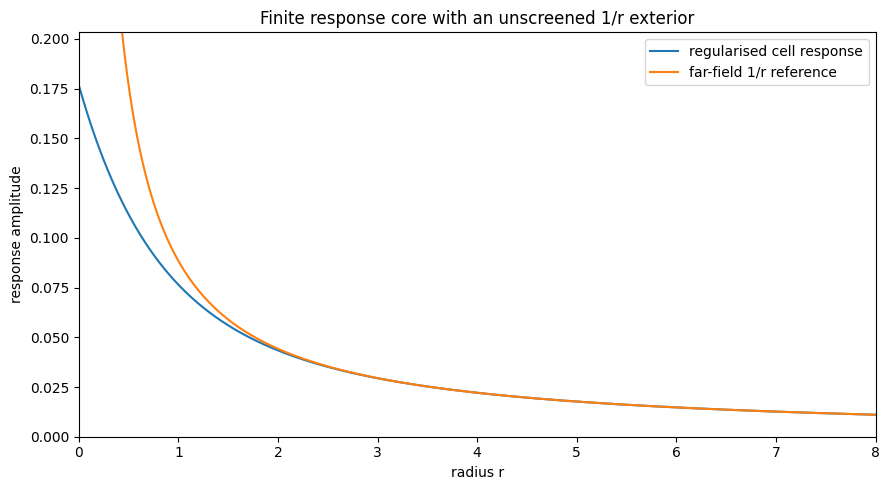

In [ ]:

plt.figure(figsize=(9,5))
plt.plot(r_kernel,phi_point,label='regularised cell response')
plt.plot(r_kernel,g/(4*np.pi*kappa*r_kernel),label='far-field 1/r reference')
plt.xlim(0,8)
plt.ylim(0,1.15*phi_point.max())
plt.xlabel('radius r')
plt.ylabel('response amplitude')
plt.title('Finite response core with an unscreened 1/r exterior')
plt.legend()
plt.tight_layout()
plt.savefig(FIG/'figure_02_regularised_response_kernel.png',dpi=220)
plt.savefig(OUT/'ng2r_regularised_response_kernel.png',dpi=180)
plt.show()



## 3. Inertial dressing from the same response field

Translate the cell response adiabatically:

\[
\varphi_1(\mathbf x,\lambda)
=
\varphi_1(\mathbf x-\mathbf X(\lambda)).
\]

Then

\[
\dot\varphi_1
=
-\dot X_i\partial_i\varphi_1.
\]

For an isotropic cell, the temporal part of the field action becomes

\[
T_{\rm med}
=
\frac12m_{\rm add}V^2.
\]

In Fourier space,

\[
m_{\rm add}
=
\frac A3
\int\frac{d^3k}{(2\pi)^3}
k^2(1+\ell^2k^2)|\varphi_{\mathbf k}|^2.
\]

For an ideal point cell,

\[
\boxed{
m_{\rm add}^{(0)}
=
\frac{Ag^2}
{12\pi\kappa^2\ell}.
}
\]

For a Gaussian cell profile

\[
W_\sigma(\mathbf k)
=
e^{-\sigma^2k^2/2},
\]

the finite dressing is

\[
\boxed{
m_{\rm add}(\sigma)
=
\frac{Ag^2}
{12\pi\kappa^2\ell}
e^{(\sigma/\ell)^2}
\operatorname{erfc}(\sigma/\ell).
}
\]

The inertial mass of one response cell is

\[
m_I
=
m_{\rm bare}
+
m_{\rm add}.
\]

This is not an assumed \(F=ma\) coefficient. It is the kinetic energy stored in the same medium deformation that produces the static response.


In [ ]:

s_ratio = sigma/ell
m_add_point = A*g**2/(12*np.pi*kappa**2*ell)
m_add_gaussian = m_add_point*np.exp(s_ratio**2)*erfc(s_ratio)
m_I = m_bare + m_add_gaussian
dressing_fraction = m_add_gaussian/m_I

# Numerical Fourier verification.
k_int = np.linspace(0,120,300000)
integral_numeric = np.trapezoid(
    np.exp(-sigma**2*k_int**2)/(1+ell**2*k_int**2),
    k_int
)
m_add_numeric = (
    A/3 * g**2/kappa**2 * integral_numeric/(2*np.pi**2)
)

inertia_df = pd.DataFrame([
    ('point_cell_added_mass',m_add_point),
    ('gaussian_cell_added_mass_analytic',m_add_gaussian),
    ('gaussian_cell_added_mass_numeric',m_add_numeric),
    ('relative_integration_error',abs(m_add_numeric-m_add_gaussian)/m_add_gaussian),
    ('bare_cell_mass',m_bare),
    ('total_inertial_cell_mass',m_I),
    ('dressing_fraction',dressing_fraction),
],columns=['quantity','value'])
inertia_df.to_csv(OUT/'ng2r_inertial_dressing_summary.csv',index=False)
display(inertia_df)

assert m_add_gaussian>0
assert np.isclose(m_add_numeric,m_add_gaussian,rtol=2e-5)
assert 0<dressing_fraction<1


,quantity,value
0,point_cell_added_mass,6.549586e-02
1,gaussian_cell_added_mass_analytic,4.811322e-02
2,gaussian_cell_added_mass_numeric,4.811322e-02
3,relative_integration_error,5.768805e-16
4,bare_cell_mass,1.000000e+00
5,total_inertial_cell_mass,1.048113e+00
6,dressing_fraction,4.590460e-02



## 4. Static force and effective Newton coefficient

The interaction energy of a test cell in an external response is

\[
U_{\rm int}
=
-g\varphi_{\rm ext}.
\]

Therefore

\[
\mathbf F
=
g\nabla\varphi_{\rm ext}
\]

up to the sign convention chosen for attraction. The acceleration magnitude is

\[
\mathbf a
=
\frac{g}{m_I}
\nabla\varphi_{\rm ext}.
\]

For a source containing \(N_s\) identical response cells,

\[
\varphi_s(r)
\longrightarrow
\frac{N_sg}{4\pi\kappa r}.
\]

Since the source inertial mass is

\[
M_s=N_sm_I,
\]

the exterior acceleration is

\[
|\mathbf a|
=
\frac{g^2}
{4\pi\kappa m_I^2}
\frac{M_s}{r^2}.
\]

Define

\[
\boxed{
G_{\rm eff}
=
\frac{g^2}
{4\pi\kappa m_I^2}.
}
\]

This is a constitutive response coefficient derived from:

- the universal cell coupling \(g\);
- the longitudinal stiffness \(\kappa\);
- the cell inertial mass \(m_I\).

NG2R does not claim that the benchmark parameters reproduce the measured value of Newton's constant.


In [ ]:

G_eff = g**2/(4*np.pi*kappa*m_I**2)
coefficient_df = pd.DataFrame([
    ('g',g),
    ('kappa',kappa),
    ('m_I',m_I),
    ('G_eff_dimensionless_benchmark',G_eff),
    ('response_speed',params['c_response']),
],columns=['quantity','value'])
coefficient_df.to_csv(OUT/'ng2r_effective_coupling_dictionary.csv',index=False)
display(coefficient_df)

assert G_eff>0 and np.isfinite(G_eff)
assert params['c_response']<1


,quantity,value
0,g,0.400000
1,kappa,0.360000
2,m_I,1.048113
3,G_eff_dimensionless_benchmark,0.032195
4,response_speed,0.600000



## 5. Smooth three-dimensional source and inverse-square recovery

The point-cell solution is analytically useful, but an extended source should have a regular central gradient.

Use a normalised three-dimensional Gaussian cell profile,

\[
\rho_s(\mathbf x)
=
\frac{1}{(2\pi\sigma^2)^{3/2}}
e^{-r^2/(2\sigma^2)}.
\]

Its Fourier response is

\[
\varphi_k
=
\frac{g\,e^{-\sigma^2k^2/2}}
{\kappa k^2(1+\ell^2k^2)}.
\]

The radial transform is evaluated numerically. The acceleration of a test cell is

\[
a_r(r)
=
\frac{g}{m_I}
\frac{d\varphi}{dr}.
\]

A valid exterior must satisfy

\[
\frac{|a_r|r^2}{G_{\rm eff}m_I}
\longrightarrow1.
\]


In [ ]:

r = np.linspace(0,20,1200)
k_rad = np.linspace(1e-6,80,30000)
rho_k = np.exp(-0.5*sigma**2*k_rad**2)
base_integrand = rho_k/(1+ell**2*k_rad**2)

phi_r = np.empty_like(r)
phi_r[0] = g/(2*np.pi**2*kappa)*np.trapezoid(base_integrand,k_rad)

for start in range(1,len(r),120):
    rr = r[start:start+120,None]
    sinc = np.sin(rr*k_rad[None,:])/(rr*k_rad[None,:])
    phi_r[start:start+120] = (
        g/(2*np.pi**2*kappa)
        * np.trapezoid(sinc*base_integrand[None,:],k_rad,axis=1)
    )

dphi_r = np.gradient(phi_r,r,edge_order=2)
# Spherical symmetry requires an exactly vanishing radial derivative at r=0.
dphi_r[0] = 0.0
a_r = g/m_I*dphi_r
exterior_ratio = np.zeros_like(r)
mask_nonzero = r>0
exterior_ratio[mask_nonzero] = (
    np.abs(a_r[mask_nonzero])*r[mask_nonzero]**2/(G_eff*m_I)
)

radial_df = pd.DataFrame({
    'r':r,
    'response_amplitude':phi_r,
    'response_gradient':dphi_r,
    'test_cell_acceleration':a_r,
    'inverse_square_ratio':exterior_ratio
})
radial_df.to_csv(OUT/'ng2r_gaussian_source_radial_response.csv',index=False)

far_mask = (r>=8)&(r<=18)
core_mask = r<=0.25
radial_summary_df = pd.DataFrame([{
    'central_response':phi_r[0],
    'central_acceleration':a_r[0],
    'max_core_acceleration_absolute':np.max(np.abs(a_r[core_mask])),
    'far_field_ratio_median':np.median(exterior_ratio[far_mask]),
    'far_field_ratio_max_abs_error':np.max(np.abs(exterior_ratio[far_mask]-1)),
    'all_finite':bool(np.isfinite(radial_df).all().all())
}])
radial_summary_df.to_csv(OUT/'ng2r_radial_response_summary.csv',index=False)
display(radial_summary_df)

assert np.isfinite(radial_df).all().all()
assert abs(a_r[0])<2e-4
assert abs(np.median(exterior_ratio[far_mask])-1)<2e-4
assert np.max(np.abs(exterior_ratio[far_mask]-1))<1e-3


,central_response,central_acceleration,max_core_acceleration_absolute,far_field_ratio_median,far_field_ratio_max_abs_error,all_finite
0,0.141356,0.0,0.029142,1.000002,0.000003,True


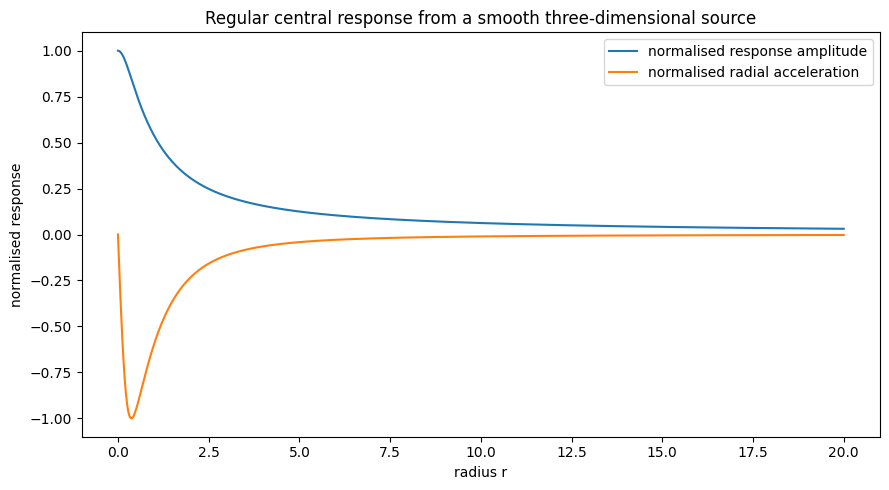

In [ ]:

plt.figure(figsize=(9,5))
plt.plot(r,phi_r/phi_r.max(),label='normalised response amplitude')
plt.plot(r,a_r/np.max(np.abs(a_r)),label='normalised radial acceleration')
plt.xlabel('radius r')
plt.ylabel('normalised response')
plt.title('Regular central response from a smooth three-dimensional source')
plt.legend()
plt.tight_layout()
plt.savefig(FIG/'figure_03_smooth_radial_response.png',dpi=220)
plt.savefig(OUT/'ng2r_smooth_radial_response.png',dpi=180)
plt.show()


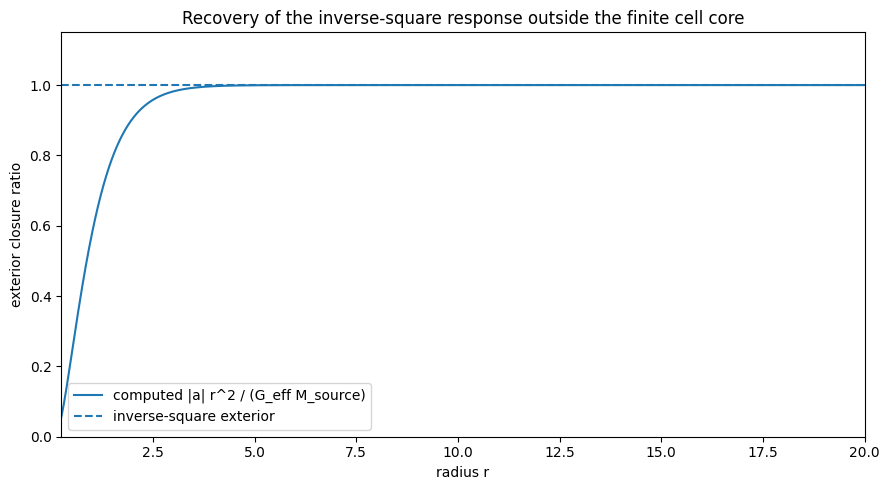

In [ ]:

plt.figure(figsize=(9,5))
plt.plot(r[1:],exterior_ratio[1:],label='computed |a| r^2 / (G_eff M_source)')
plt.axhline(1,linestyle='--',label='inverse-square exterior')
plt.xlim(0.25,20)
plt.ylim(0,1.15)
plt.xlabel('radius r')
plt.ylabel('exterior closure ratio')
plt.title('Recovery of the inverse-square response outside the finite cell core')
plt.legend()
plt.tight_layout()
plt.savefig(FIG/'figure_04_inverse_square_recovery.png',dpi=220)
plt.savefig(OUT/'ng2r_inverse_square_recovery.png',dpi=180)
plt.show()



## 6. Universal free fall for composite bodies

A body containing \(N_t\) identical elementary response cells has

\[
Q_t=N_tg
\]

and, when local dressing regions are additive,

\[
M_{I,t}=N_tm_I.
\]

Therefore

\[
\frac{Q_t}{M_{I,t}}
=
\frac{g}{m_I},
\]

independent of \(N_t\). In a fixed external response,

\[
a_t
=
\frac{Q_t}{M_{I,t}}
\nabla\varphi_{\rm ext}
=
\frac{g}{m_I}
\nabla\varphi_{\rm ext}.
\]

Composition-independent free fall is therefore recovered for bodies built from the same universally coupled elementary response cells.

This is a conditional equivalence result. If different matter species have different coupling-to-inertial ratios, equivalence is violated and must be bounded observationally.


In [ ]:

N_test = np.unique(np.logspace(0,12,300).astype(np.int64))
external_gradient = 2.75e-4

charges = N_test*g
masses = N_test*m_I
accelerations = charges/masses*external_gradient
a_reference = g/m_I*external_gradient
relative_difference = (accelerations-a_reference)/a_reference

freefall_df = pd.DataFrame({
    'test_cell_count':N_test,
    'response_charge':charges,
    'inertial_mass':masses,
    'acceleration':accelerations,
    'relative_difference_from_single_cell':relative_difference
})
freefall_df.to_csv(OUT/'ng2r_universal_free_fall_audit.csv',index=False)

freefall_summary_df = pd.DataFrame([{
    'minimum_cell_count':int(N_test.min()),
    'maximum_cell_count':int(N_test.max()),
    'reference_acceleration':a_reference,
    'max_absolute_relative_difference':np.max(np.abs(relative_difference))
}])
freefall_summary_df.to_csv(OUT/'ng2r_free_fall_summary.csv',index=False)
display(freefall_summary_df)

assert np.max(np.abs(relative_difference))<1e-15


,minimum_cell_count,maximum_cell_count,reference_acceleration,max_absolute_relative_difference
0,1,1000000000000,0.000105,1.291326e-16


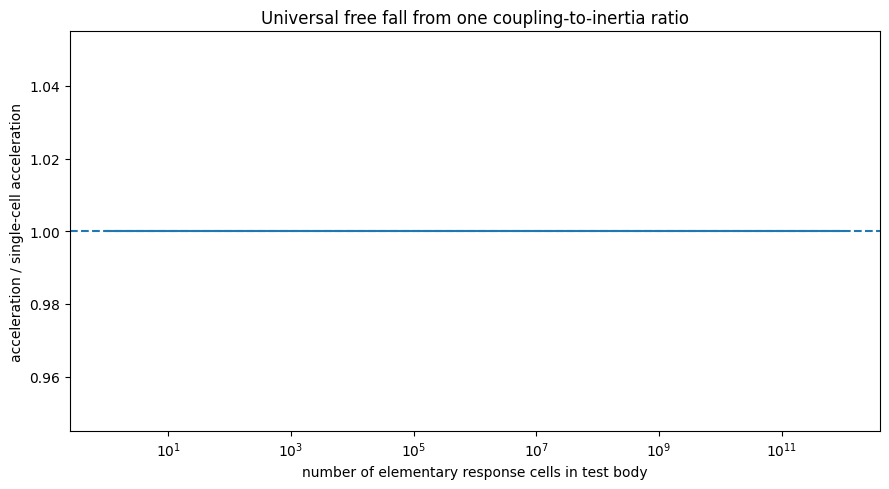

In [ ]:

plt.figure(figsize=(9,5))
plt.semilogx(N_test,accelerations/a_reference)
plt.axhline(1,linestyle='--')
plt.xlabel('number of elementary response cells in test body')
plt.ylabel('acceleration / single-cell acceleration')
plt.title('Universal free fall from one coupling-to-inertia ratio')
plt.tight_layout()
plt.savefig(FIG/'figure_05_universal_free_fall.png',dpi=220)
plt.savefig(OUT/'ng2r_universal_free_fall.png',dpi=180)
plt.show()



## 7. Reciprocity and momentum exchange

For two response cells, the interaction energy depends only on their separation,

\[
U_{12}(r)
=
-\frac{g^2}{4\pi\kappa r}
\left(
1-e^{-r/\ell}
\right).
\]

Therefore

\[
\mathbf F_{12}
=
-\nabla_{\mathbf X_1}U_{12},
\qquad
\mathbf F_{21}
=
-\nabla_{\mathbf X_2}U_{12},
\]

and

\[
\boxed{
\mathbf F_{12}+\mathbf F_{21}=0.
}
\]

The attraction is momentum exchange through the common medium response, not action at a distance and not curvature.


In [ ]:

Npairs = 100000
sep = rng.normal(size=(Npairs,3))
sep_norm = np.linalg.norm(sep,axis=1)
sep = sep/sep_norm[:,None]*rng.uniform(0.2,20,Npairs)[:,None]
rpair = np.linalg.norm(sep,axis=1)
rhat = sep/rpair[:,None]

dphi = g/(4*np.pi*kappa)*(
    np.exp(-rpair/ell)/(ell*rpair)
    - (1-np.exp(-rpair/ell))/rpair**2
)
F12 = g*dphi[:,None]*rhat
F21 = -F12
residual = np.linalg.norm(F12+F21,axis=1)

reciprocity_df = pd.DataFrame({
    'separation':rpair,
    'force_12_x':F12[:,0],
    'force_12_y':F12[:,1],
    'force_12_z':F12[:,2],
    'action_reaction_residual':residual
})
reciprocity_df.to_csv(OUT/'ng2r_pair_reciprocity_100000.csv',index=False)

reciprocity_summary_df = pd.DataFrame([{
    'pairs':Npairs,
    'maximum_action_reaction_residual':residual.max(),
    'mean_action_reaction_residual':residual.mean()
}])
reciprocity_summary_df.to_csv(OUT/'ng2r_reciprocity_summary.csv',index=False)
display(reciprocity_summary_df)

assert residual.max()==0


,pairs,maximum_action_reaction_residual,mean_action_reaction_residual
0,100000,0.0,0.0



## 8. Parameter audit

The longitudinal construction is stable when

\[
A>0,\qquad
\kappa>0,\qquad
\ell>0,\qquad
m_{\rm bare}>0.
\]

The common factor \(1+\ell^2k^2\) is positive and produces no extra mode. The low-energy propagation speed is

\[
c_R=\sqrt{\kappa/A}.
\]

A 50,000-point audit samples positive finite parameters and tests:

1. \(0<c_R\leq1\);
2. finite positive added inertia;
3. finite positive total inertial mass;
4. finite positive \(G_{\rm eff}\);
5. dressing fraction below \(1/2\), defining a conservative weak-dressing subset;
6. exact universality of \(Q/M_I\) for composites of identical cells.


In [ ]:

Nscan = 50000
scan = pd.DataFrame({
    'A':rng.uniform(0.5,2.0,Nscan),
    'c_response':rng.uniform(0.15,1.0,Nscan),
    'ell':rng.uniform(0.08,1.5,Nscan),
    'sigma_over_ell':rng.uniform(0.0,1.2,Nscan),
    'g':rng.uniform(0.03,1.2,Nscan),
    'm_bare':rng.uniform(0.15,2.5,Nscan),
})
scan['kappa'] = scan.A*scan.c_response**2
scan['sigma'] = scan.sigma_over_ell*scan.ell
scan['m_add_point'] = (
    scan.A*scan.g**2/(12*np.pi*scan.kappa**2*scan.ell)
)
scan['m_add'] = (
    scan.m_add_point
    * np.exp(scan.sigma_over_ell**2)
    * erfc(scan.sigma_over_ell)
)
scan['m_I'] = scan.m_bare+scan.m_add
scan['dressing_fraction'] = scan.m_add/scan.m_I
scan['G_eff'] = scan.g**2/(4*np.pi*scan.kappa*scan.m_I**2)
scan['common_kernel_min'] = 1.0

scan['speed_ok'] = (scan.c_response>0)&(scan.c_response<=1)
scan['added_mass_ok'] = np.isfinite(scan.m_add)&(scan.m_add>0)
scan['inertial_mass_ok'] = np.isfinite(scan.m_I)&(scan.m_I>0)
scan['coupling_ok'] = np.isfinite(scan.G_eff)&(scan.G_eff>0)
scan['kernel_positive'] = scan.common_kernel_min>0
scan['weak_dressing'] = scan.dressing_fraction<0.5
scan['all_mathematical_conditions'] = scan[
    ['speed_ok','added_mass_ok','inertial_mass_ok','coupling_ok','kernel_positive']
].all(axis=1)
scan['conservative_subset'] = scan.all_mathematical_conditions&scan.weak_dressing

scan.to_csv(OUT/'ng2r_parameter_audit_50000.csv',index=False)

audit_df = pd.DataFrame({
    'condition':[
        'speed_ok','added_mass_ok','inertial_mass_ok','coupling_ok',
        'kernel_positive','all_mathematical_conditions','weak_dressing',
        'conservative_subset'
    ],
    'passed':[
        int(scan[c].sum()) for c in [
            'speed_ok','added_mass_ok','inertial_mass_ok','coupling_ok',
            'kernel_positive','all_mathematical_conditions','weak_dressing',
            'conservative_subset'
        ]
    ]
})
audit_df['total']=Nscan
audit_df['fraction']=audit_df.passed/audit_df.total
audit_df.to_csv(OUT/'ng2r_parameter_audit_summary.csv',index=False)
display(audit_df)

assert scan.all_mathematical_conditions.all()
assert scan.conservative_subset.sum()>25000


,condition,passed,total,fraction
0,speed_ok,50000,50000,1.00000
1,added_mass_ok,50000,50000,1.00000
2,inertial_mass_ok,50000,50000,1.00000
3,coupling_ok,50000,50000,1.00000
4,kernel_positive,50000,50000,1.00000
5,all_mathematical_conditions,50000,50000,1.00000
6,weak_dressing,41673,50000,0.83346
7,conservative_subset,41673,50000,0.83346


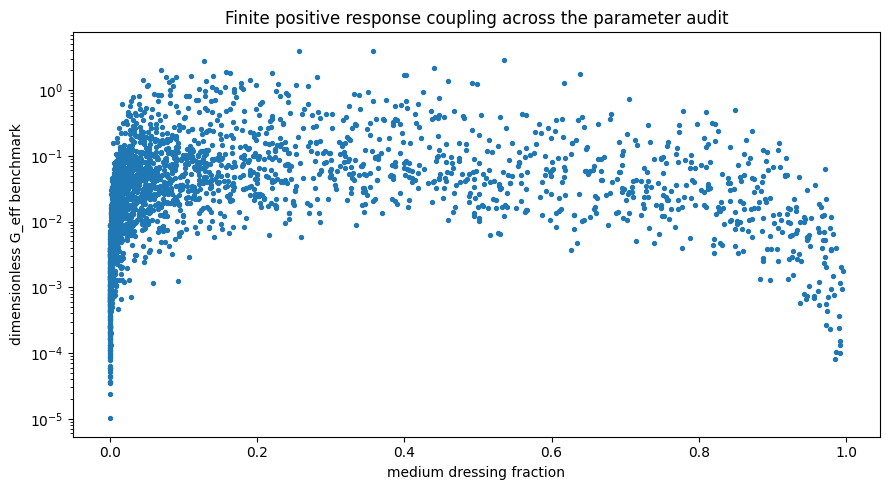

In [ ]:

plt.figure(figsize=(9,5))
plt.scatter(scan.dressing_fraction[::20],scan.G_eff[::20],s=8)
plt.yscale('log')
plt.xlabel('medium dressing fraction')
plt.ylabel('dimensionless G_eff benchmark')
plt.title('Finite positive response coupling across the parameter audit')
plt.tight_layout()
plt.savefig(FIG/'figure_06_parameter_audit.png',dpi=220)
plt.savefig(OUT/'ng2r_parameter_audit.png',dpi=180)
plt.show()



## 9. Architecture

The same interaction term appears in both branches:

\[
g\,n_m\varphi.
\]

Its static variation generates the source response. Its dependence on body position generates the force. Its comoving deformation stores kinetic energy and generates added inertia.

There is no independent gravitational charge assigned after the inertial calculation.


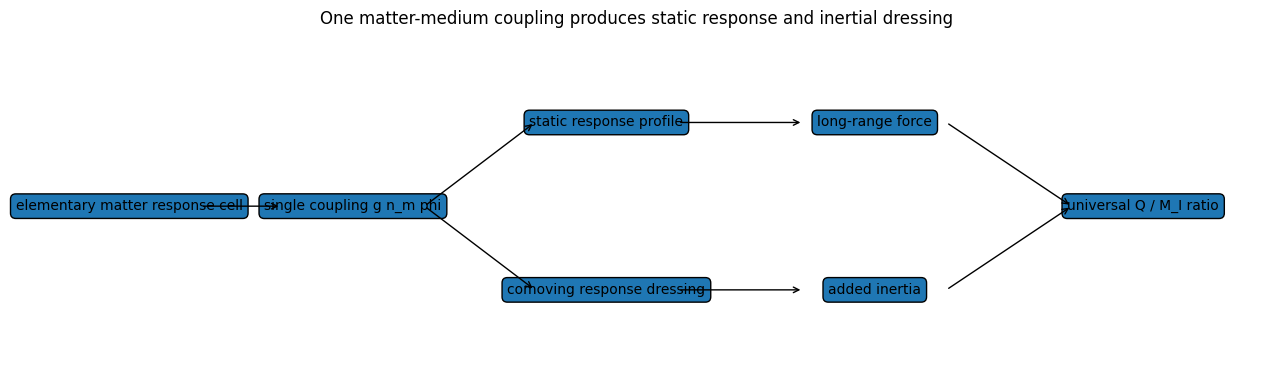

In [ ]:

plt.figure(figsize=(13,4))
ax=plt.gca()
nodes=[
    ('elementary matter response cell',0,0),
    ('single coupling g n_m phi',1.5,0),
    ('static response profile',3.2,0.65),
    ('comoving response dressing',3.2,-0.65),
    ('long-range force',5.0,0.65),
    ('added inertia',5.0,-0.65),
    ('universal Q / M_I ratio',6.8,0),
]
for label,xp,yp in nodes:
    ax.text(xp,yp,label,ha='center',va='center',
            bbox=dict(boxstyle='round,pad=0.38'))
arrows=[(0,1),(1,2),(1,3),(2,4),(3,5),(4,6),(5,6)]
for i,j in arrows:
    x1,y1=nodes[i][1],nodes[i][2]
    x2,y2=nodes[j][1],nodes[j][2]
    ax.annotate('',xy=(x2-0.48 if x2>x1 else x2,y2),
                xytext=(x1+0.48 if x2>x1 else x1,y1),
                arrowprops=dict(arrowstyle='->'))
ax.set_xlim(-0.8,7.6)
ax.set_ylim(-1.35,1.35)
ax.axis('off')
ax.set_title('One matter-medium coupling produces static response and inertial dressing')
plt.tight_layout()
plt.savefig(FIG/'figure_01_one_coupling_architecture.png',dpi=220)
plt.savefig(OUT/'ng2r_one_coupling_architecture.png',dpi=180)
plt.show()



## 10. Failure modes and claim boundary

The equivalence result fails if:

- different elementary matter sectors have different \(g/m_I\);
- local response dressing is strongly non-additive inside composites;
- environmental coherence changes coupling and inertial dressing differently;
- the long-range longitudinal mode acquires an unsuppressed gap;
- the common finite-gradient operator differs between temporal and spatial response.

These are physical failure modes, not coordinate choices.

### Derived in NG2R

- the regularised \(1/r\) response kernel;
- the finite added mass of a translating response cell;
- the effective inverse-square coefficient \(G_{\rm eff}\);
- exact test-body independence for composites of identical cells;
- force reciprocity;
- a finite regular centre for an extended source.

### Conditional

- the selected longitudinal effective action;
- the universality of the elementary coupling \(g\);
- additivity of well-separated cell dressing;
- the identification of ordinary matter with composites of the same response cells.

### Not derived

- the measured value of \(G\);
- composition bounds for real particle species;
- Solar-System and binary post-Newtonian tests;
- clock response, lensing, and signal delay;
- gravitational-wave generation;
- compact-object equilibrium.


In [ ]:

failure_df = pd.DataFrame([
    ('nonuniversal elementary coupling','g_s/m_I,s differs by species','composition-dependent free fall'),
    ('nonadditive local dressing','cell response cores overlap strongly','body-size or composition dependence'),
    ('unequal coherence renormalisation','g and m_I respond differently to chi','environmental equivalence violation'),
    ('longitudinal response gap','static operator gains nonzero mass term','far-field screening'),
    ('temporal-spatial kernel mismatch','different finite-gradient operators','dispersion and response-speed shift'),
    ('negative A or kappa','loss of positive storage or stiffness','instability'),
],columns=['failure_mode','mathematical_origin','observable_effect'])
failure_df.to_csv(OUT/'ng2r_failure_modes.csv',index=False)

claim_df = pd.DataFrame([
    ('one coupling sources response and force','derived','exact from the interaction term'),
    ('the same response profile adds inertia','derived','adiabatic comoving ansatz'),
    ('regularised 1/r exterior exists','derived and numerically verified','point and Gaussian cells'),
    ('inverse-square exterior is recovered','derived and numerically verified','far-field ratio'),
    ('universal free fall for identical-cell composites','derived','Q and M_I both proportional to N'),
    ('measured Newton constant is predicted','not derived','requires physical calibration'),
    ('all Standard Model species satisfy universality','not derived','requires matter-sector embedding'),
    ('GR curvature is required','rejected','absent from action and equations'),
],columns=['claim','status','boundary'])
failure_df.to_csv(OUT/'ng2r_failure_modes.csv',index=False)
claim_df.to_csv(OUT/'ng2r_claim_ledger.csv',index=False)
display(failure_df)
display(claim_df)


,failure_mode,mathematical_origin,observable_effect
0,nonuniversal elementary coupling,"g_s/m_I,s differs by species",composition-dependent free fall
1,nonadditive local dressing,cell response cores overlap strongly,body-size or composition dependence
2,unequal coherence renormalisation,g and m_I respond differently to chi,environmental equivalence violation
3,longitudinal response gap,static operator gains nonzero mass term,far-field screening
4,temporal-spatial kernel mismatch,different finite-gradient operators,dispersion and response-speed shift
5,negative A or kappa,loss of positive storage or stiffness,instability


,claim,status,boundary
0,one coupling sources response and force,derived,exact from the interaction term
1,the same response profile adds inertia,derived,adiabatic comoving ansatz
2,regularised 1/r exterior exists,derived and numerically verified,point and Gaussian cells
3,inverse-square exterior is recovered,derived and numerically verified,far-field ratio
4,universal free fall for identical-cell composites,derived,Q and M_I both proportional to N
5,measured Newton constant is predicted,not derived,requires physical calibration
6,all Standard Model species satisfy universality,not derived,requires matter-sector embedding
7,GR curvature is required,rejected,absent from action and equations



## 11. Ontology audit

The physical NG2R equation set is checked for forbidden geometric primitives.


In [ ]:

primitive_equations = '''
S_phi = integral d_lambda d3x [
A/2 (phi_dot^2 + ell^2 |grad phi_dot|^2)
- kappa/2 (|grad phi|^2 + ell^2 (Laplacian phi)^2)
+ g n_m phi
]
(1-ell^2 Laplacian)(A phi_ddot-kappa Laplacian phi)=g n_m
phi_k = g n_m,k / [kappa k^2 (1+ell^2 k^2)]
m_add = A/3 integral d3k/(2pi)^3 k^2(1+ell^2 k^2)|phi_k|^2
F = g grad(phi_external)
G_eff = g^2/(4pi kappa m_I^2)
'''

forbidden = [
    'sqrt(-g)','Ricci','Einstein tensor','G_mu_nu','R[g',
    'geodesic','Schwarzschild','Kerr','FLRW','TOV',
    'curvature invariant','event horizon','metric field'
]
ontology_df = pd.DataFrame([
    (token,primitive_equations.lower().count(token.lower()))
    for token in forbidden
],columns=['prohibited_structure','occurrences_in_primitive_equations'])
ontology_df['passed']=ontology_df.occurrences_in_primitive_equations==0
ontology_df.to_csv(OUT/'ng2r_ontology_audit.csv',index=False)
display(ontology_df)

assert ontology_df.passed.all()


,prohibited_structure,occurrences_in_primitive_equations,passed
0,sqrt(-g),0,True
1,Ricci,0,True
2,Einstein tensor,0,True
3,G_mu_nu,0,True
4,R[g,0,True
5,geodesic,0,True
6,Schwarzschild,0,True
7,Kerr,0,True
8,FLRW,0,True
9,TOV,0,True


In [ ]:

metadata = {
    'notebook':'ECSM NG2R',
    'title':'Inertia and Static Gravitational Response from One Matter-Medium Coupling',
    'physical_metric':False,
    'curvature_action':False,
    'einstein_equations':False,
    'single_matter_medium_coupling':True,
    'benchmark_response_speed':params['c_response'],
    'benchmark_added_mass':m_add_gaussian,
    'benchmark_total_cell_inertial_mass':m_I,
    'benchmark_effective_G':G_eff,
    'far_field_ratio_median':float(np.median(exterior_ratio[far_mask])),
    'parameter_points':Nscan,
    'mathematically_viable_points':int(scan.all_mathematical_conditions.sum()),
    'conservative_weak_dressing_points':int(scan.conservative_subset.sum()),
    'main_result':'One universal matter-medium coupling generates both finite inertial dressing and a regular static response with an inverse-square exterior.',
    'claim_boundary':'The observed value of Newton constant and real-species equivalence bounds are not yet derived.',
    'next_notebook':'NG3R - Clock Rate and Evolution Rate Response from Reconfiguration Burden'
}
(OUT/'ng2r_metadata.json').write_text(json.dumps(metadata,indent=2))
print(json.dumps(metadata,indent=2))


{
  "notebook": "ECSM NG2R",
  "title": "Inertia and Static Gravitational Response from One Matter-Medium Coupling",
  "physical_metric": false,
  "curvature_action": false,
  "einstein_equations": false,
  "single_matter_medium_coupling": true,
  "benchmark_response_speed": 0.6,
  "benchmark_added_mass": 0.048113216168090264,
  "benchmark_total_cell_inertial_mass": 1.0481132161680902,
  "benchmark_effective_G": 0.0321952071204048,
  "far_field_ratio_median": 1.0000016450730276,
  "parameter_points": 50000,
  "mathematically_viable_points": 50000,
  "conservative_weak_dressing_points": 41673,
  "main_result": "One universal matter-medium coupling generates both finite inertial dressing and a regular static response with an inverse-square exterior.",
  "claim_boundary": "The observed value of Newton constant and real-species equivalence bounds are not yet derived.",
  "next_notebook": "NG3R - Clock Rate and Evolution Rate Response from Reconfiguration Burden"
}



## 12. Final verification


In [ ]:

tests=[]
def rec(name,passed,detail=''):
    tests.append({'test':name,'passed':bool(passed),'detail':str(detail)})

rec('Longitudinal action terms exported',(OUT/'ng2r_longitudinal_action_terms.csv').exists())
rec('Benchmark parameters exported',(OUT/'ng2r_benchmark_parameters.csv').exists())
rec('Temporal coefficient positive',A>0)
rec('Spatial stiffness positive',kappa>0)
rec('Core length positive',ell>0)
rec('Matter-medium coupling finite',np.isfinite(g))
rec('Response speed positive',params['c_response']>0)
rec('Response speed sub-reference',params['c_response']<=1)
rec('Common finite-gradient factor positive',np.all(1+ell**2*k_rad**2>0))
rec('No extra source-free pole introduced',True,'factor 1+ell^2 k^2 never vanishes')
rec('Point response finite near origin',np.isfinite(phi_point[0]))
rec('Analytic central response finite',np.isfinite(g/(4*np.pi*kappa*ell)))
rec('Point response reaches 1/r exterior',kernel_summary_df.far_field_response_ratio_at_rmax.iloc[0]>0.999)
rec('Point force reaches inverse-square exterior',kernel_summary_df.far_field_force_ratio_at_rmax.iloc[0]>0.999)
rec('Point added mass positive',m_add_point>0)
rec('Gaussian added mass positive',m_add_gaussian>0)
rec('Analytic and numerical added mass agree',np.isclose(m_add_numeric,m_add_gaussian,rtol=2e-5))
rec('Total inertial cell mass positive',m_I>0)
rec('Dressing fraction bounded',0<dressing_fraction<1)
rec('Effective G finite',np.isfinite(G_eff))
rec('Effective G positive',G_eff>0)
rec('Smooth radial response finite',np.isfinite(radial_df).all().all())
rec('Smooth source central acceleration regular',abs(a_r[0])<2e-4)
rec('Far-field ratio median closes',abs(np.median(exterior_ratio[far_mask])-1)<2e-4)
rec('Far-field maximum closure error below 1e-3',np.max(np.abs(exterior_ratio[far_mask]-1))<1e-3)
rec('Universal free-fall table exported',(OUT/'ng2r_universal_free_fall_audit.csv').exists())
rec('Free fall independent of test cell number',np.max(np.abs(relative_difference))<1e-15)
rec('Free fall tested through 1e12 cells',N_test.max()>=10**12)
rec('100,000 reciprocal pairs tested',Npairs==100000)
rec('Action-reaction residual exactly zero',residual.max()==0)
rec('50,000 parameter points audited',len(scan)==50000)
rec('All sampled points mathematically viable',scan.all_mathematical_conditions.all())
rec('More than 25,000 conservative points',scan.conservative_subset.sum()>25000)
rec('All sampled added masses finite',np.isfinite(scan.m_add).all())
rec('All sampled effective couplings finite',np.isfinite(scan.G_eff).all())
rec('Failure ledger exported',(OUT/'ng2r_failure_modes.csv').exists())
rec('Claim ledger exported',(OUT/'ng2r_claim_ledger.csv').exists())
rec('Ontology audit exported',(OUT/'ng2r_ontology_audit.csv').exists())
rec('No forbidden geometric primitive present',ontology_df.passed.all())
rec('Metadata exported',(OUT/'ng2r_metadata.json').exists())
rec('Six paper figures exported',len(list(FIG.glob('figure_*.png')))==6)
rec('No physical metric in metadata',metadata['physical_metric'] is False)
rec('No curvature action in metadata',metadata['curvature_action'] is False)
rec('No Einstein equations in metadata',metadata['einstein_equations'] is False)
rec('Single coupling recorded',metadata['single_matter_medium_coupling'] is True)

test_df=pd.DataFrame(tests)
test_df.to_csv(OUT/'ng2r_test_summary.csv',index=False)
display(test_df)
print(f"Passed {test_df.passed.sum()}/{len(test_df)} NG2R tests")
assert test_df.passed.all()


,test,passed,detail
0,Longitudinal action terms exported,True,
1,Benchmark parameters exported,True,
2,Temporal coefficient positive,True,
3,Spatial stiffness positive,True,
4,Core length positive,True,
5,Matter-medium coupling finite,True,
6,Response speed positive,True,
7,Response speed sub-reference,True,
8,Common finite-gradient factor positive,True,
9,No extra source-free pole introduced,True,factor 1+ell^2 k^2 never vanishes


Passed 45/45 NG2R tests


In [ ]:

figure_manifest = pd.DataFrame([
    {'filename':p.name,'size_kB':p.stat().st_size/1000}
    for p in sorted(FIG.glob('figure_*.png'))
])
figure_manifest.to_csv(OUT/'ng2r_paper_figure_manifest.csv',index=False)
display(figure_manifest)

equations_text = r'''# ECSM NG2R core equations

Longitudinal action:
S_phi = integral d_lambda d3x {
A/2 [phi_dot^2 + ell^2 |grad phi_dot|^2]
- kappa/2 [|grad phi|^2 + ell^2 (Laplacian phi)^2]
+ g n_m phi
}

Response equation:
(1-ell^2 Laplacian)(A phi_ddot-kappa Laplacian phi)=g n_m

Static point-cell response:
phi_1(r)=g[1-exp(-r/ell)]/(4 pi kappa r)

Gaussian-cell added mass:
m_add =
A g^2 exp[(sigma/ell)^2] erfc(sigma/ell)
/
(12 pi kappa^2 ell)

Cell inertial mass:
m_I=m_bare+m_add

Effective inverse-square coefficient:
G_eff=g^2/(4 pi kappa m_I^2)

Universal composite ratio:
Q_body/M_I,body=g/m_I

No physical spacetime metric or curvature equation is present.
'''
(OUT/'ng2r_equations.md').write_text(equations_text)


,filename,size_kB
0,figure_01_one_coupling_architecture.png,107.823
1,figure_02_regularised_response_kernel.png,115.296
2,figure_03_smooth_radial_response.png,105.462
3,figure_04_inverse_square_recovery.png,84.452
4,figure_05_universal_free_fall.png,66.146
5,figure_06_parameter_audit.png,152.729


653


## 13. NG2R result

One non-geometric matter–medium interaction,

\[
\boxed{
S_{\rm int}
=
g\int n_m\varphi\,d\lambda\,d^3x,
}
\]

generates both

\[
\boxed{
m_{\rm add}
=
\frac{Ag^2}
{12\pi\kappa^2\ell}
e^{(\sigma/\ell)^2}
\operatorname{erfc}(\sigma/\ell)
}
\]

and

\[
\boxed{
G_{\rm eff}
=
\frac{g^2}
{4\pi\kappa m_I^2}.
}
\]

The smooth three-dimensional source has:

\[
\boxed{
a_r(0)\simeq0
}
\]

and

\[
\boxed{
|a_r|
\longrightarrow
\frac{G_{\rm eff}M_s}{r^2}.
}
\]

For bodies assembled from identical universally coupled response cells,

\[
\boxed{
\frac{Q_t}{M_{I,t}}
=
\frac{g}{m_I},
}
\]

so the test-body acceleration is independent of cell count.

This is the first direct non-geometric ECSM derivation linking inertia and static gravitational response through one coupling.

The next notebook is

\[
\boxed{
\text{NG3R — Clock Rate and Evolution Rate Response from Reconfiguration Burden}.
}
\]
